<h1 style="font-family:verdana;"> <center> 💫World Air Quality Index | EDA ⛅</center> </h1>
<p><center style="color:#159364; font-family:cursive;">Data Analytics, EDA</center></p>

***

![AQI.png](attachment:161e331f-b91a-4588-9af3-9c7d38e09de8.png)

# 1. Introduction

In this notebook, we will perform Exploratory Data Analysis (EDA) on the World Air Quality Index dataset. The dataset contains information about air quality measurements in different cities around the world. We will explore the data, visualize key insights, and derive meaningful analytics from it.

| **About Dataset**                                                                                                   |
| ------------------------------------------------------------------------------------------------------------------- |
| **Sulfur Dioxide (SO2):** SO2 is a gas produced by the burning of fossil fuels, particularly in industrial processes. It can have harmful effects on human health, leading to respiratory issues and exacerbating asthma and other respiratory conditions. |
| **Nitrogen Dioxide (NO2):** NO2 is a gas produced by the burning of fossil fuels, primarily in vehicles and power plants. Exposure to high levels of NO2 can irritate the respiratory system and contribute to the development of respiratory conditions. |
| **Air Quality Index (AQI):** AQI is a measure used to communicate the level of air pollution in a specific area. It is often calculated based on the concentrations of various pollutants, such as PM2.5, ozone, CO, SO2, and NO2. The AQI provides a standardized scale to help individuals understand the air quality and take necessary precautions to protect their health. |
| **Good:** The "Good" category on the AQI scale indicates that the air quality is satisfactory, and there is little to no health risk associated with it. |
| **Moderate:** The "Moderate" category signifies that the air quality is acceptable, but there may be a moderate health concern for a small number of individuals, particularly those who are unusually sensitive to air pollution. |
| **Unhealthy for Sensitive Groups:** This category indicates that the air quality is of concern for individuals who are more vulnerable to the effects of air pollution, such as children, older adults, and people with respiratory or cardiovascular conditions. |
| **Unhealthy:** The "Unhealthy" category suggests that the general population may start to experience health effects due to the poor air quality. It is advisable to limit outdoor activities and take necessary precautions. |
| **Very Unhealthy:** The "Very Unhealthy" category signifies a significant health risk from the air pollution. It is recommended to avoid outdoor activities and minimize exposure to the polluted air. |
| **Hazardous:** The "Hazardous" category indicates the highest level of air pollution, posing a severe health risk. It is crucial to stay indoors, use air filtration systems, and follow local authorities' guidance to protect health. |


# 2. Dataset Overview
Let's start by loading the dataset and getting a brief overview of its contents.

In [ ]:
# Import necessary libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
import pandas as pd

# Load the dataset
california_data = pd.read_csv("/content/sample_data/california_housing_train.csv")

# Display the first few rows of the dataset
california_data.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
0,-114.31,34.19,15.0,5612.0,1283.0,1015.0,472.0,1.4936,66900.0
1,-114.47,34.40,19.0,7650.0,1901.0,1129.0,463.0,1.8200,80100.0
2,-114.56,33.69,17.0,720.0,174.0,333.0,117.0,1.6509,85700.0
3,-114.57,33.64,14.0,1501.0,337.0,515.0,226.0,3.1917,73400.0
4,-114.57,33.57,20.0,1454.0,326.0,624.0,262.0,1.9250,65500.0


# 3. Data Cleaning and Preprocessing

Before diving into the analysis, it's important to clean and preprocess the data to ensure accurate and meaningful results. We will handle missing values, remove irrelevant columns, and perform any necessary transformations.



In [ ]:
california_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17000 entries, 0 to 16999
Data columns (total 9 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           17000 non-null  float64
 1   latitude            17000 non-null  float64
 2   housing_median_age  17000 non-null  float64
 3   total_rooms         17000 non-null  float64
 4   total_bedrooms      17000 non-null  float64
 5   population          17000 non-null  float64
 6   households          17000 non-null  float64
 7   median_income       17000 non-null  float64
 8   median_house_value  17000 non-null  float64
dtypes: float64(9)
memory usage: 1.2 MB


Dataset contains **16,695 rows** and ****14 columns.** Here is a summary of the columns and their data types:

| #   | Column              | Dtype    |
| --- | ------              | -----    |
| 0   | Country             | object   |
| 1   | City                | object   |
| 2   | AQI Value           | int64    |
| 3   | AQI Category        | object   |
| 4   | CO AQI Value        | int64    |
| 5   | CO AQI Category     | object   |
| 6   | Ozone AQI Value     | int64    |
| 7   | Ozone AQI Category  | object   |
| 8   | NO2 AQI Value       | int64    |
| 9   | NO2 AQI Category    | object   |
| 10  | PM2.5 AQI Value     | int64    |
| 11  | PM2.5 AQI Category  | object   |
| 12  | lat                 | float64  |
| 13  | lng                 | float64  |


In [ ]:
california_data.columns

Index(['longitude', 'latitude', 'housing_median_age', 'total_rooms',
       'total_bedrooms', 'population', 'households', 'median_income',
       'median_house_value'],
      dtype='object')

In [ ]:
california_data.describe(include ='all')

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,17000.000000,17000.000000,17000.000000,17000.000000,17000.000000,17000.000000,17000.000000,17000.000000,17000.000000
mean,-119.562108,35.625225,28.589353,2643.664412,539.410824,1429.573941,501.221941,3.883578,207300.912353
std,2.005166,2.137340,12.586937,2179.947071,421.499452,1147.852959,384.520841,1.908157,115983.764387
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.790000,33.930000,18.000000,1462.000000,297.000000,790.000000,282.000000,2.566375,119400.000000
50%,-118.490000,34.250000,29.000000,2127.000000,434.000000,1167.000000,409.000000,3.544600,180400.000000
75%,-118.000000,37.720000,37.000000,3151.250000,648.250000,1721.000000,605.250000,4.767000,265000.000000
max,-114.310000,41.950000,52.000000,37937.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


In [ ]:
print(california_data.columns)

Index(['longitude', 'latitude', 'housing_median_age', 'total_rooms',
       'total_bedrooms', 'population', 'households', 'median_income',
       'median_house_value'],
      dtype='object')


Based on the provided summary statistics of the dataset, we can derive the following insights:

1. **Air Quality Index (AQI) Value:** The average AQI value is approximately 63, with a minimum of 7 and a maximum of 500. This indicates a wide range of air quality conditions across the cities in the dataset.

1. **Pollutant Categories:** The dataset includes AQI values and categories for various pollutants such as **CO, Ozone, NO2, and PM2.5.** The most frequently recorded pollutant category is **"Good"** for all pollutants, suggesting that a majority of the cities have relatively satisfactory air quality.

1. **Geographical Distribution:** The dataset covers cities from 174 different countries. The most frequently represented country is the **United States of America**, with 3,954 occurrences. This indicates that the dataset is heavily skewed towards cities in the United States.

1. **Geographic Coordinates:** The dataset includes latitude and longitude coordinates for each city, providing spatial information for further analysis and visualization.

In [ ]:
california_data.isnull().sum()

,0
longitude,0
latitude,0
housing_median_age,0
total_rooms,0
total_bedrooms,0
population,0
households,0
median_income,0
median_house_value,0


In [ ]:
california_data.dropna(axis=1, inplace=True)

# 4. Exploratory Data Analysis
Now, let's explore the dataset to gain insights into the air quality measurements. We will analyze various aspects such as pollutant levels, geographical distribution, and temporal patterns.

**Distribution of the AQI Values**

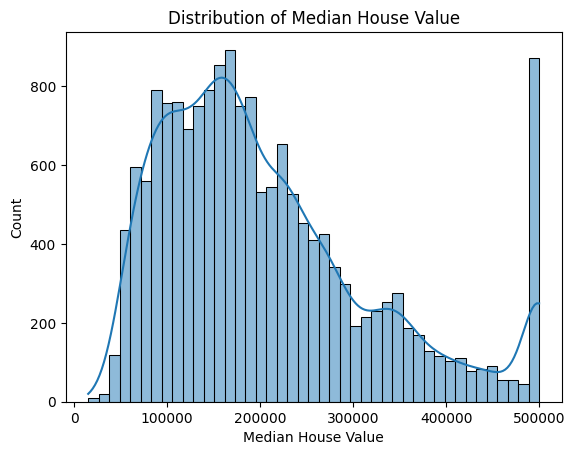

In [ ]:
sns.histplot(california_data['median_house_value'], kde=True)
plt.title('Distribution of Median House Value')
plt.xlabel('Median House Value')
plt.ylabel('Count')
plt.show()

**Relationship between AQI Value and other variables**

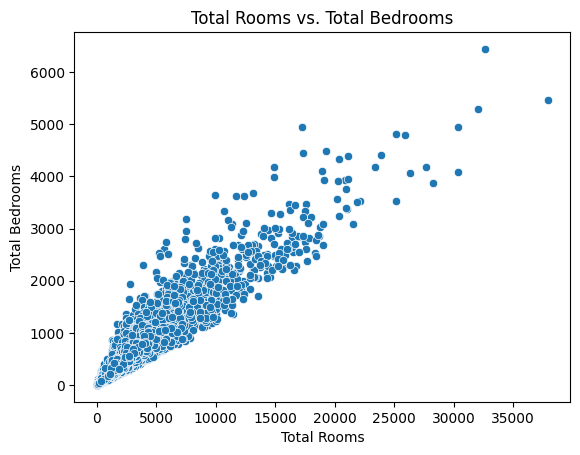

In [ ]:
sns.scatterplot(data=california_data, x='total_rooms', y='total_bedrooms')
plt.title('Total Rooms vs. Total Bedrooms')
plt.xlabel('Total Rooms')
plt.ylabel('Total Bedrooms')
plt.show()

### Relationship between Median Income and Median House Value

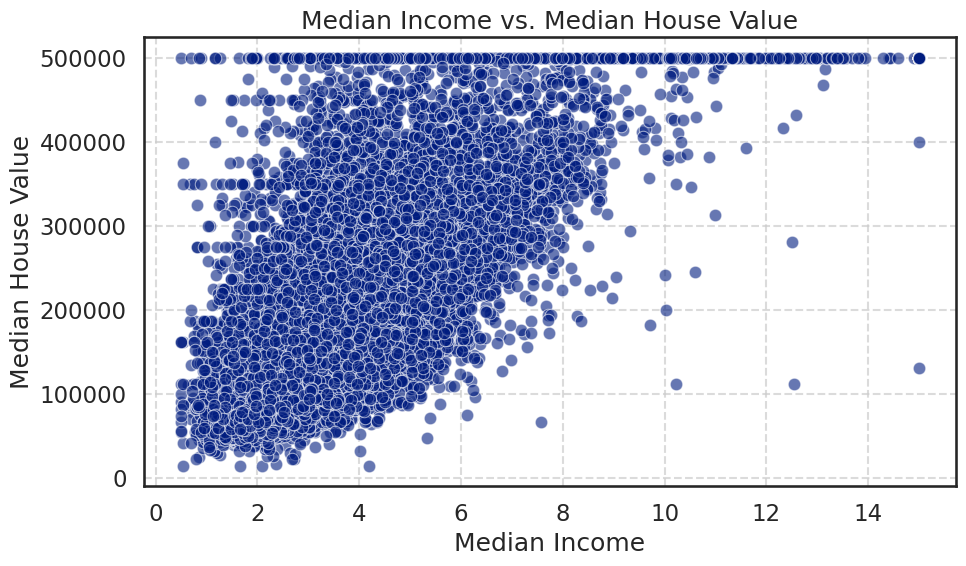

In [ ]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=california_data, x='median_income', y='median_house_value', alpha=0.6)
plt.title('Median Income vs. Median House Value')
plt.xlabel('Median Income')
plt.ylabel('Median House Value')
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

**Distribution of AQI categories**

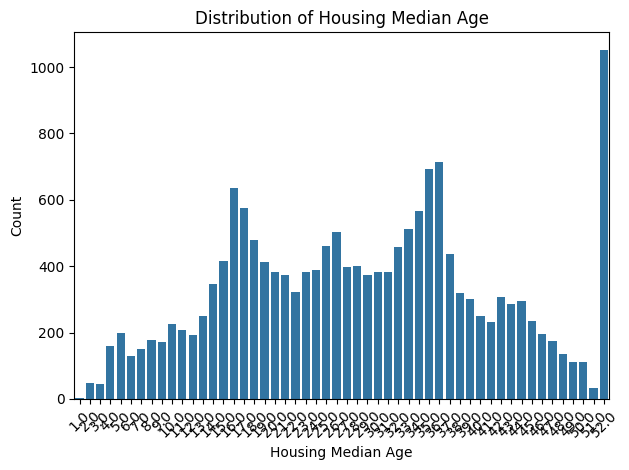

In [ ]:
sns.countplot(data=california_data, x='housing_median_age')
plt.title('Distribution of Housing Median Age')
plt.xlabel('Housing Median Age')
plt.ylabel('Count')
plt.xticks(rotation=45)  # Rotate x-axis labels by 45 degrees
plt.tight_layout()  # Adjust the plot layout to prevent overlapping
plt.show()

The countplot of AQI Categories by Country provides an overview of the distribution of air quality across different countries. It allows us to see the frequency of each AQI category (Good, Moderate, Unhealthy for Sensitive Groups, etc.) within each country. This information can help us identify countries with higher or lower air quality levels.

**AQI Category vs. AQI Value**

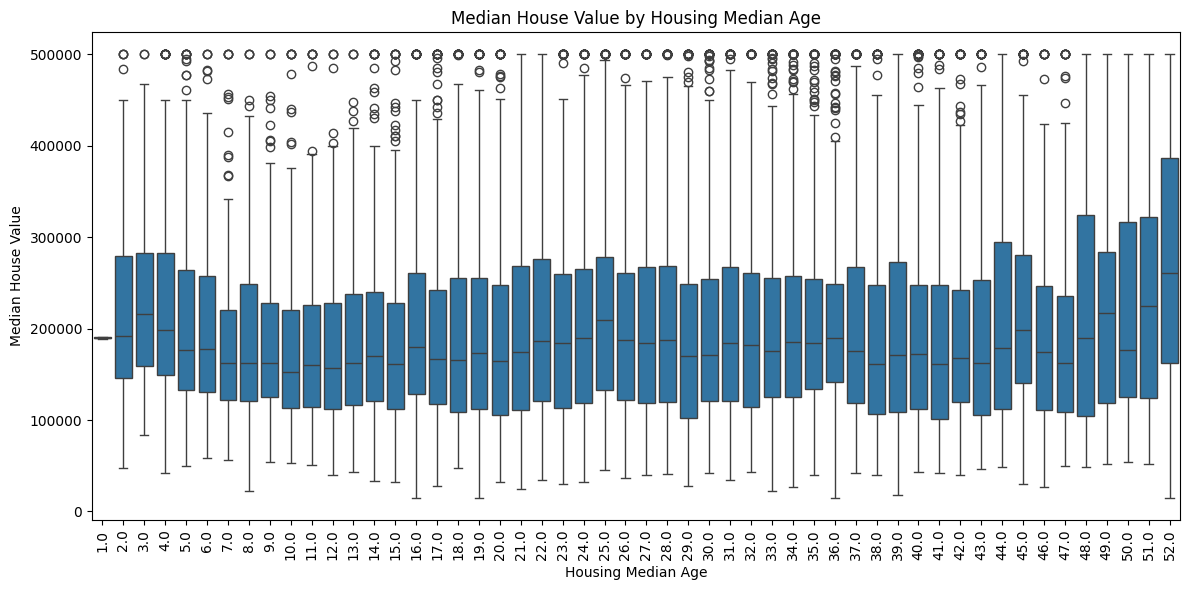

In [ ]:
plt.figure(figsize=(12, 6))
sns.boxplot(data=california_data, x='housing_median_age', y='median_house_value')
plt.title('Median House Value by Housing Median Age')
plt.xlabel('Housing Median Age')
plt.ylabel('Median House Value')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

**Geographic distribution of cities**

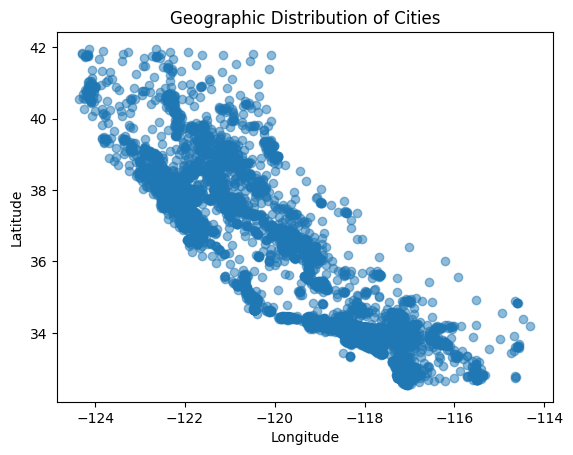

In [ ]:
plt.scatter(california_data['longitude'], california_data['latitude'], alpha=0.5)
plt.title('Geographic Distribution of Cities')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.show()

**Comparison of AQI Categories by Pollutant**

**Correlation Matrix of Pollutant AQI Values**

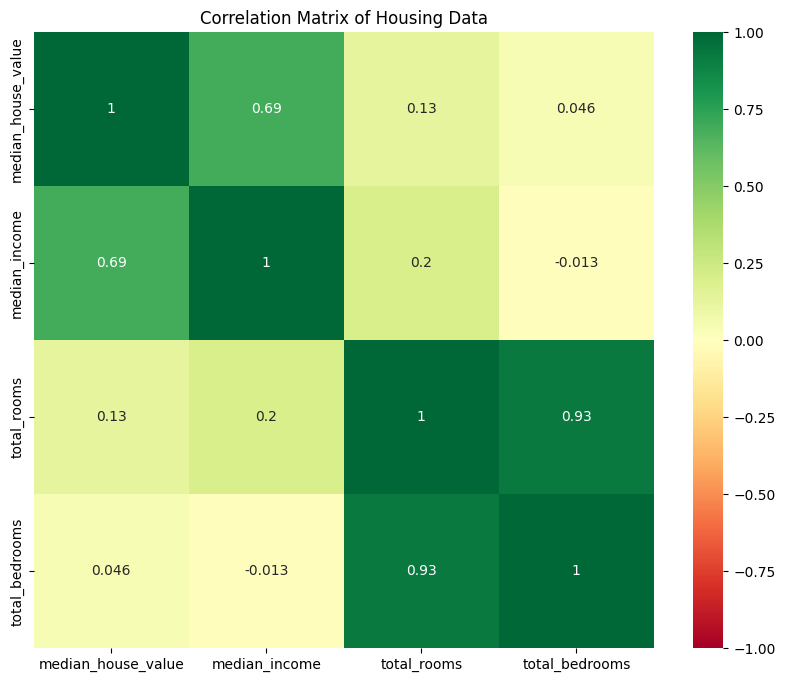

In [ ]:
corr_matrix = california_data[['median_house_value', 'median_income', 'total_rooms', 'total_bedrooms']].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='RdYlGn', vmin=-1, vmax=1)
plt.title('Correlation Matrix of Housing Data')
plt.show()

In [ ]:
corr_matrix

,median_house_value,median_income,total_rooms,total_bedrooms
median_house_value,1.000000,0.691871,0.130991,0.045783
median_income,0.691871,1.000000,0.195383,-0.013495
total_rooms,0.130991,0.195383,1.000000,0.928403
total_bedrooms,0.045783,-0.013495,0.928403,1.000000


The correlation matrix shows the relationships between AQI values of different pollutants, including CO, Ozone, NO2, and PM2.5. It helps us understand the degree of association between these pollutants and how they contribute to the overall air quality index. The correlation values indicate whether the AQI values of different pollutants tend to increase or decrease together.

**Scatterplot Matrix of Pollutant AQI Values**

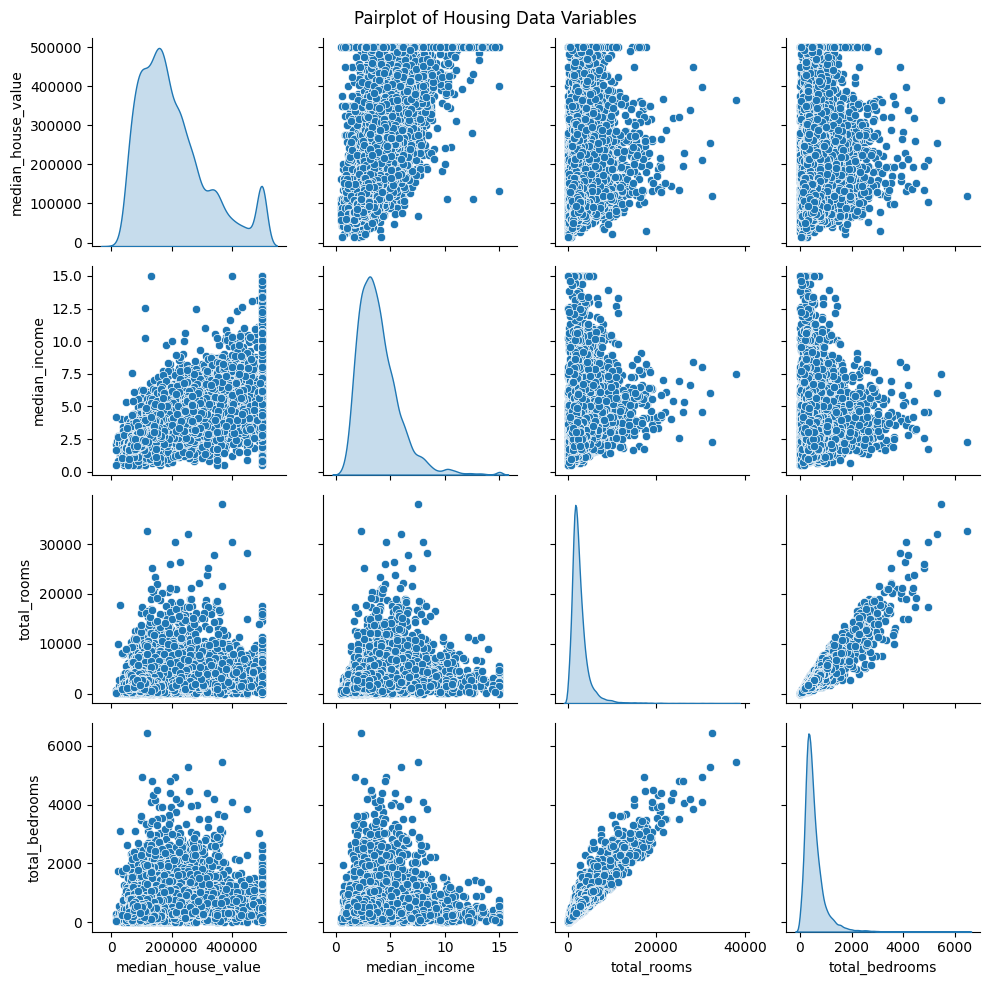

In [ ]:
sns.pairplot(data=california_data, vars=['median_house_value', 'median_income', 'total_rooms', 'total_bedrooms'], diag_kind='kde')
plt.suptitle('Pairplot of Housing Data Variables')
plt.tight_layout()
plt.show()

In [ ]:
data.columns

**Top polluted Cities**

# 5. Conclusion

Based on the exploratory data analysis (EDA) conducted on the provided air quality dataset, the following conclusions can be drawn:

* **Overall Air Quality:** The majority of the recorded AQI values fall within the "Good" to "Moderate" categories, indicating relatively acceptable air quality in many locations. However, there are also instances of higher AQI values, indicating poorer air quality.

* **Pollutant Contribution:** Among the pollutants measured, PM2.5, NO2, CO, and Ozone are the major contributors to air pollution. These pollutants show varying levels of correlation with each other, suggesting potential interactions and shared sources.

* **Top Polluted Countries:** The analysis highlights the countries with consistently poor air quality based on the recorded AQI values. Identifying these countries can aid in directing resources and interventions to improve air quality in those regions.

* **Geospatial Analysis:** Visualizing the geographic distribution of air quality using latitude and longitude coordinates helps identify areas with higher pollution levels. Certain regions may exhibit clusters of polluted areas, indicating localized sources of pollution.

In conclusion, the EDA provides valuable insights into air quality, pollutant contributions, geographical patterns, and potential avenues for further analysis. These findings can inform decision-making processes, policy formulation, and targeted interventions aimed at improving air quality and mitiga

In [ ]:
# IMPORTANT: RUN THIS CELL IN ORDER TO IMPORT YOUR KAGGLE DATA SOURCES,
# THEN FEEL FREE TO DELETE THIS CELL.
# NOTE: THIS NOTEBOOK ENVIRONMENT DIFFERS FROM KAGGLE'S PYTHON
# ENVIRONMENT SO THERE MAY BE MISSING LIBRARIES USED BY YOUR
# NOTEBOOK.
import kagglehub
uciml_iris_path = kagglehub.dataset_download('uciml/iris')

print('Data source import complete.')


Using Colab cache for faster access to the 'iris' dataset.
Data source import complete.


In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import warnings
warnings.filterwarnings('ignore')
# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All"
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/iris/Iris.csv
/kaggle/input/iris/database.sqlite


![](https://cdn-images-1.medium.com/max/1000/1*gwmXliaxIBkY4NQBhoe9JQ.png)

**REFERENCES - Some of the graph ideas in this kernel are taken from https://avinashkz.com/data/visualization/2017/09/28/seaborn.html**

# Dataset overview
The data set consists of 50 samples from each of three species Iris setosa, Iris virginica and Iris versicolor. 4 features were measured from each sample: the length and the width of the sepals and petals, in centimeters.

In [ ]:
df = pd.read_csv('/kaggle/input/iris/Iris.csv')
df.head()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa


In [ ]:
#make the Id column as index
df = pd.read_csv('/kaggle/input/iris/Iris.csv', index_col='Id')
df.tail()

,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
Id,,,,,
146,6.7,3.0,5.2,2.3,Iris-virginica
147,6.3,2.5,5.0,1.9,Iris-virginica
148,6.5,3.0,5.2,2.0,Iris-virginica
149,6.2,3.4,5.4,2.3,Iris-virginica
150,5.9,3.0,5.1,1.8,Iris-virginica


In [ ]:
#Rename columns
df.rename({'SepalLengthCm': 'sepal_length',
           'SepalWidthCm': 'sepal_width',
           'PetalLengthCm': 'petal_length',
           'PetalWidthCm': 'petal_width',
           'Species': 'species'
          }, inplace=True,axis=1)
df.sample(5)

,sepal_length,sepal_width,petal_length,petal_width,species
Id,,,,,
122,5.6,2.8,4.9,2.0,Iris-virginica
109,6.7,2.5,5.8,1.8,Iris-virginica
48,4.6,3.2,1.4,0.2,Iris-setosa
5,5.0,3.6,1.4,0.2,Iris-setosa
10,4.9,3.1,1.5,0.1,Iris-setosa


In [ ]:
#calculate median of each species
x = df.groupby('species').median()
x

,sepal_length,sepal_width,petal_length,petal_width
species,,,,
Iris-setosa,5.0,3.4,1.50,0.2
Iris-versicolor,5.9,2.8,4.35,1.3
Iris-virginica,6.5,3.0,5.55,2.0


In [ ]:
#Statistics of this dataset
stats = df.describe()
stats

,sepal_length,sepal_width,petal_length,petal_width
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.054000,3.758667,1.198667
std,0.828066,0.433594,1.764420,0.763161
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


In [ ]:
#calculate range, and move columns 25%,50%,75%  and mean values into a dataframe
stats.loc['range'] = stats.loc['max'] - stats.loc['min']
new_df = stats.loc[['mean', 'range', '25%', '50%', '75%']]
new_df.rename({'50%': 'median'}, inplace=True)
new_df

,sepal_length,sepal_width,petal_length,petal_width
mean,5.843333,3.054,3.758667,1.198667
range,3.600000,2.400,5.900000,2.400000
25%,5.100000,2.800,1.600000,0.300000
median,5.800000,3.000,4.350000,1.300000
75%,6.400000,3.300,5.100000,1.800000


# Aggregation functions

In [ ]:
#Calculate mean and median or others using multiple functions at once - 2 methods

df.groupby('species').agg(['mean', 'median'])  # passing a list of recognized strings
df.groupby('species').agg([np.mean, np.median])

sepal_length        sepal_width        petal_length         \
                        mean median        mean median         mean median   
species                                                                      
Iris-setosa            5.006    5.0       3.418    3.4        1.464   1.50   
Iris-versicolor        5.936    5.9       2.770    2.8        4.260   4.35   
Iris-virginica         6.588    6.5       2.974    3.0        5.552   5.55   

                petal_width         
                       mean median  
species                             
Iris-setosa           0.244    0.2  
Iris-versicolor       1.326    1.3  
Iris-virginica        2.026    2.0

In [ ]:
#If we want an explicit aggr function like max for a column
agg_dict={field: ['mean', 'median'] for  field in df.columns.tolist() if field != 'species'}
agg_dict['petal_length'] = 'max'
df.groupby('species').agg(agg_dict)

sepal_length        sepal_width        petal_length  \
                        mean median        mean median          max   
species                                                               
Iris-setosa            5.006    5.0       3.418    3.4          1.9   
Iris-versicolor        5.936    5.9       2.770    2.8          5.1   
Iris-virginica         6.588    6.5       2.974    3.0          6.9   

                petal_width         
                       mean median  
species                             
Iris-setosa           0.244    0.2  
Iris-versicolor       1.326    1.3  
Iris-virginica        2.026    2.0

# Visualisations

In [ ]:
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns

# Distribution Plot

Text(0.5, 1.0, 'Distribution of petal-width')

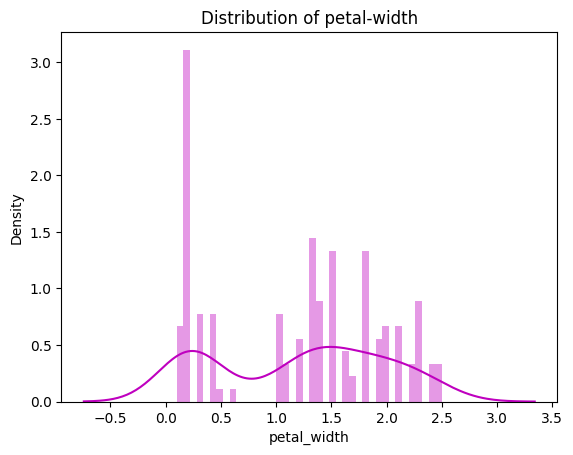

In [ ]:
sns.distplot(a=df['petal_width'], bins=40, color='m')
plt.title('Distribution of petal-width')

# Count plot
**displays the number of observations for a categorical variable using bars.**

<Axes: xlabel='species', ylabel='count'>

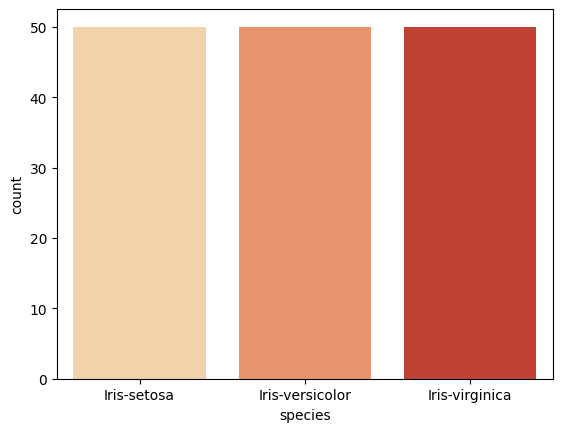

In [ ]:
sns.countplot(x='species',data=df, palette="OrRd")

# Box Plot
**shows the distribution of quantitative data across a categorical variable.**

<Axes: xlabel='species', ylabel='sepal_width'>

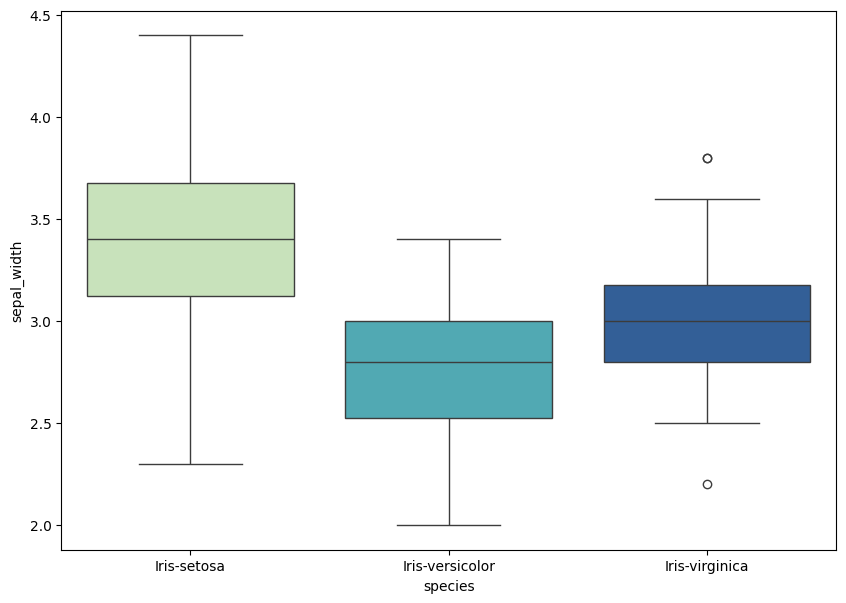

In [ ]:
plt.figure(figsize=(10,7))
sns.boxplot(x='species',y='sepal_width',data=df ,palette='YlGnBu')

# violin plot
This is a variation of box plot. It shows the distribution of quantitative data across several levels of categorical variables. The violin plot also features a kde of the underlying distribution

<Axes: xlabel='species', ylabel='petal_length'>

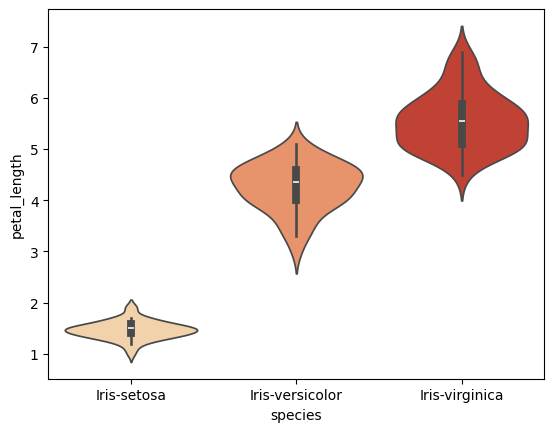

In [ ]:
sns.violinplot(x='species', y='petal_length', data=df, palette='OrRd')

# Matrix plots
1. HeatMap -  It provides the graph of the correlation matrix.
2. Cluster Map - It is a plot of matrix dataset as a hierarchically clustered heatmap.

<Axes: >

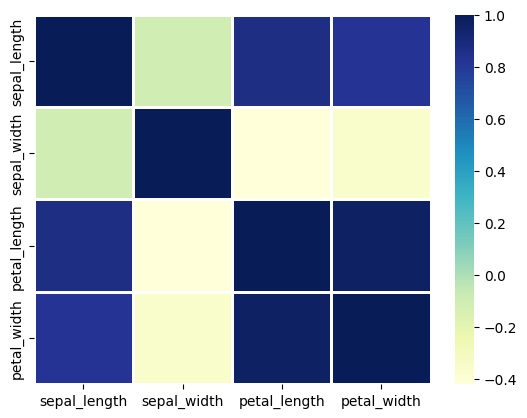

In [ ]:
sns.heatmap(df.drop('species', axis=1).corr(),cmap="YlGnBu", linecolor='white', linewidths=1)

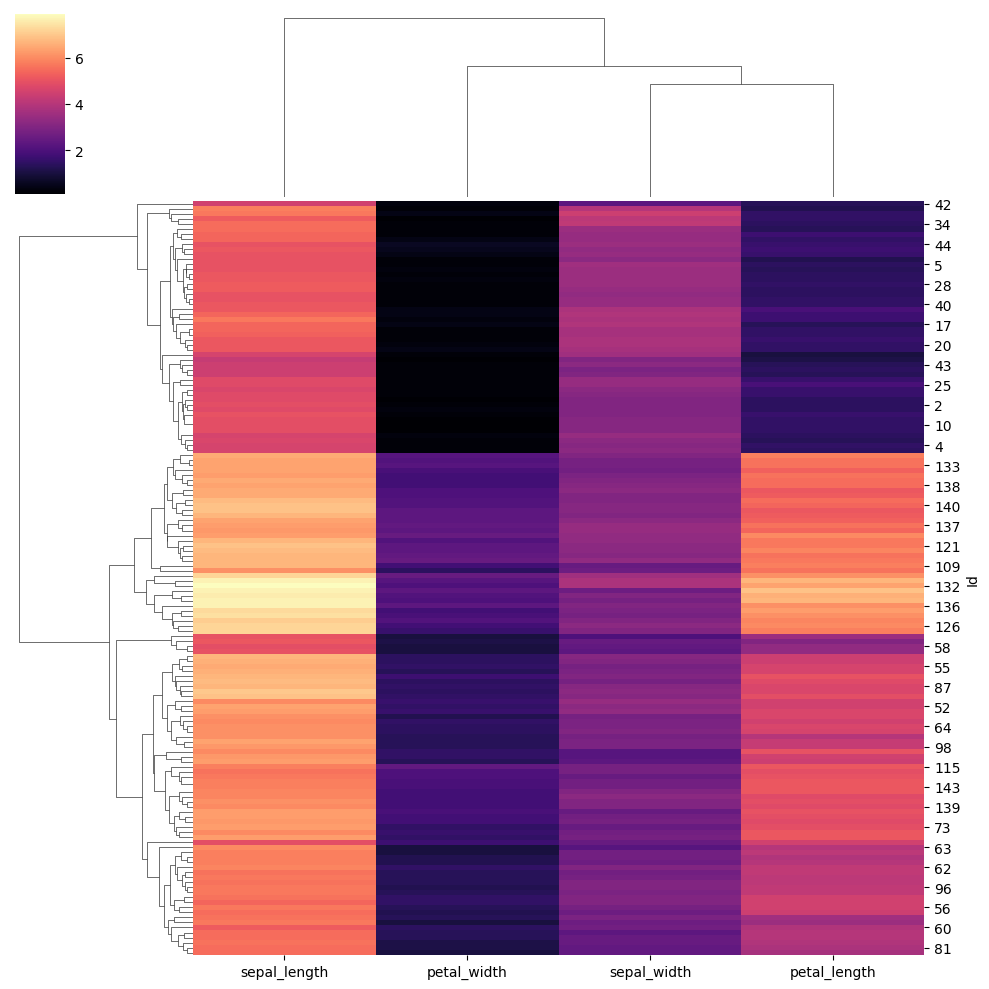

In [ ]:
#Cluster map takes only quantitative variables, so we need to do some processing here.
x = df.drop('species',axis=1)
g = sns.clustermap(x, cmap="magma")

# Regression Plots

<Axes: xlabel='petal_width', ylabel='petal_length'>

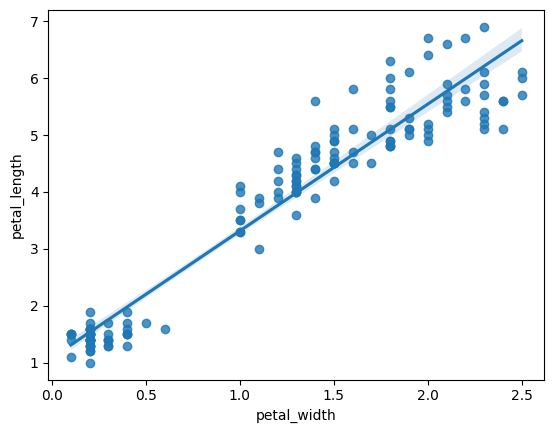

In [ ]:
sns.regplot(x='petal_width', y='petal_length', data=df)

# Axis Grids - These are graphs that combine various plots using FacetGrid to realize complex visualizations.

# LM Plots

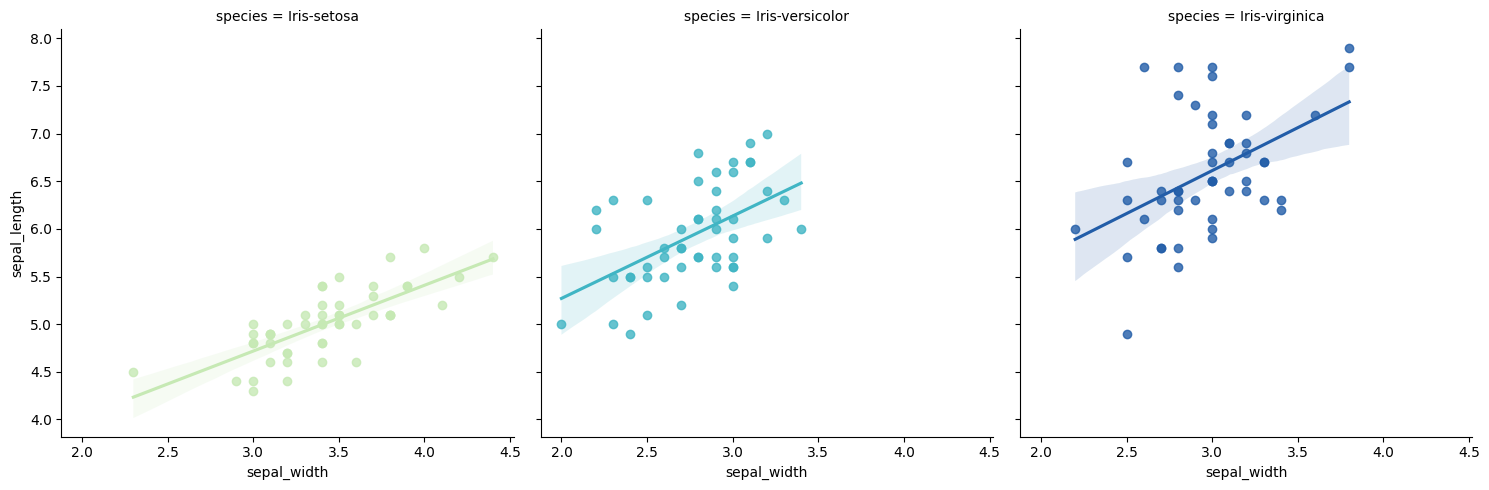

In [ ]:
sns.lmplot(x = 'sepal_width', y = 'sepal_length', data = df, col = 'species', hue = 'species', palette = 'YlGnBu')

# Joint Plot
**Used to draw a plot of two variables with bivariate and univariate graphs.**

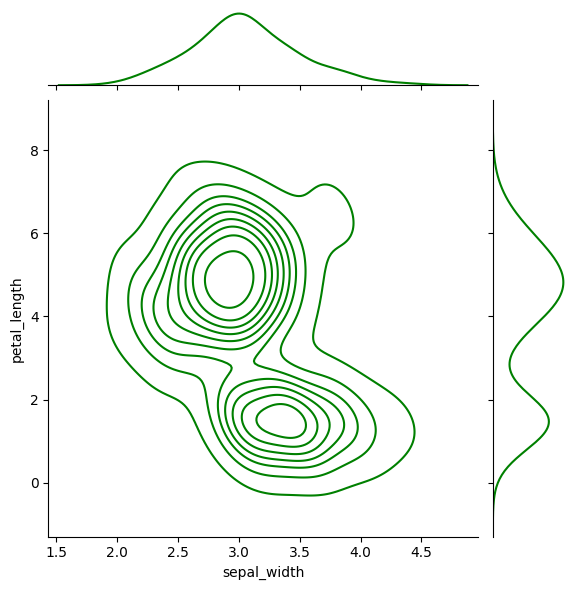

In [ ]:
sns.jointplot(x="sepal_width", y="petal_length", data=df, kind="kde", color="g")

# Scatterplot

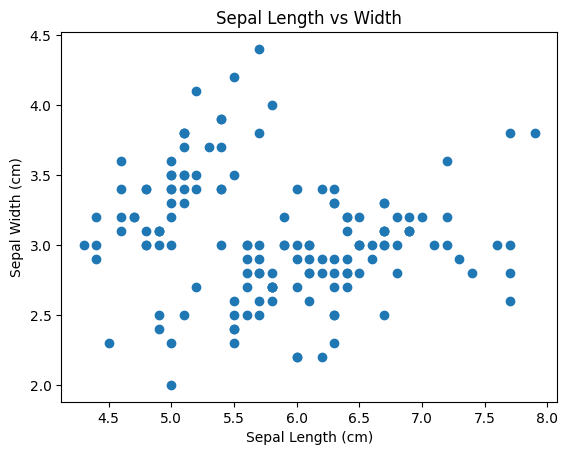

In [ ]:
ax = plt.axes()

ax.scatter(df.sepal_length, df.sepal_width)

# Label the axes
ax.set(xlabel='Sepal Length (cm)',
       ylabel='Sepal Width (cm)',
       title='Sepal Length vs Width');

# Histograms

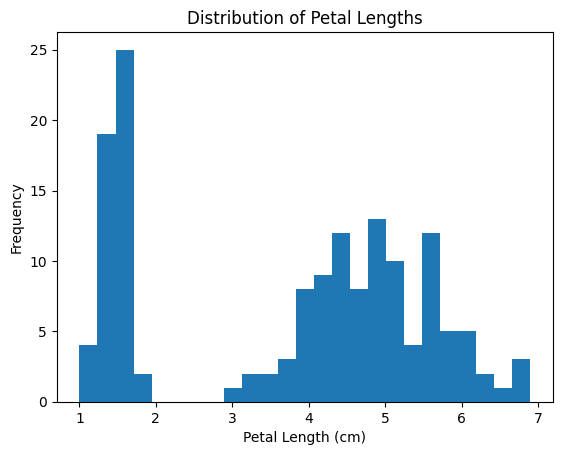

In [ ]:
ax = plt.axes()
ax.hist(df.petal_length, bins=25);

ax.set(xlabel='Petal Length (cm)',
       ylabel='Frequency',
       title='Distribution of Petal Lengths');

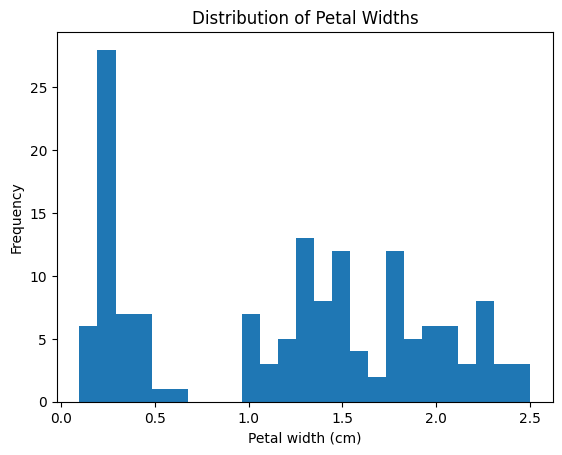

In [ ]:
ax = plt.axes()
ax.hist(df.petal_width, bins=25);

ax.set(xlabel='Petal width (cm)',
       ylabel='Frequency',
       title='Distribution of Petal Widths');

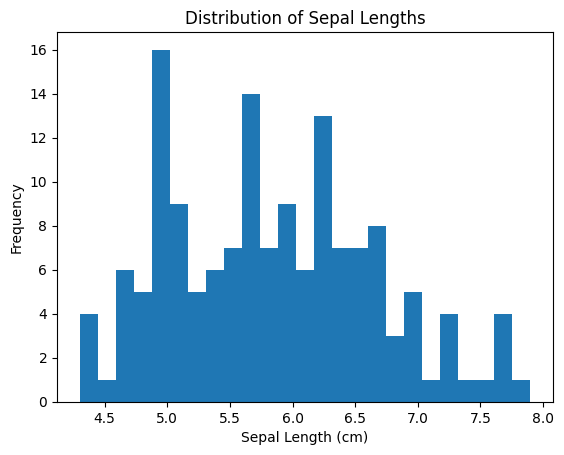

In [ ]:
ax = plt.axes()
ax.hist(df.sepal_length, bins=25);

ax.set(xlabel='Sepal Length (cm)',
       ylabel='Frequency',
       title='Distribution of Sepal Lengths');

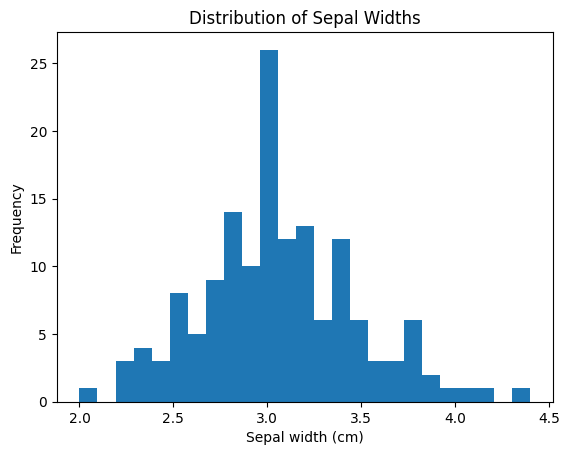

In [ ]:
ax = plt.axes()
ax.hist(df.sepal_width, bins=25);

ax.set(xlabel='Sepal width (cm)',
       ylabel='Frequency',
       title='Distribution of Sepal Widths');

# TAKE-AWAY From the histograms, we observe that Petal length and petal width are influencing variables for the different species

# plot histogram using pandas

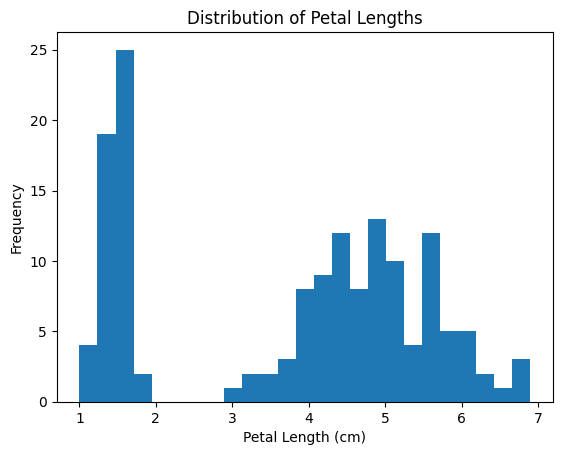

In [ ]:
ax = df.petal_length.plot.hist(bins=25)

ax.set(xlabel='Petal Length (cm)',
       ylabel='Frequency',
       title='Distribution of Petal Lengths');

# plotting all histograms

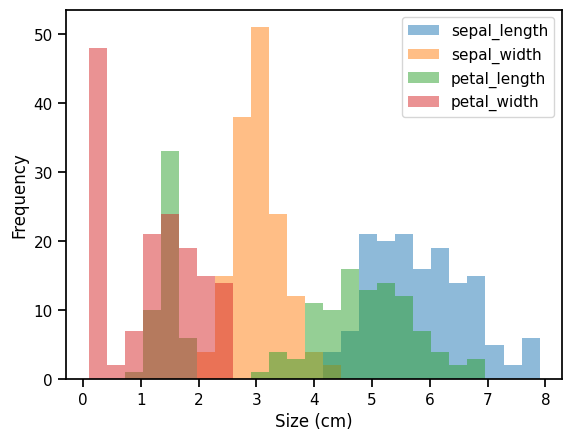

In [ ]:
import seaborn as sns
sns.set_context('notebook')


ax = df.plot.hist(bins=25, alpha=0.5)
ax.set_xlabel('Size (cm)');

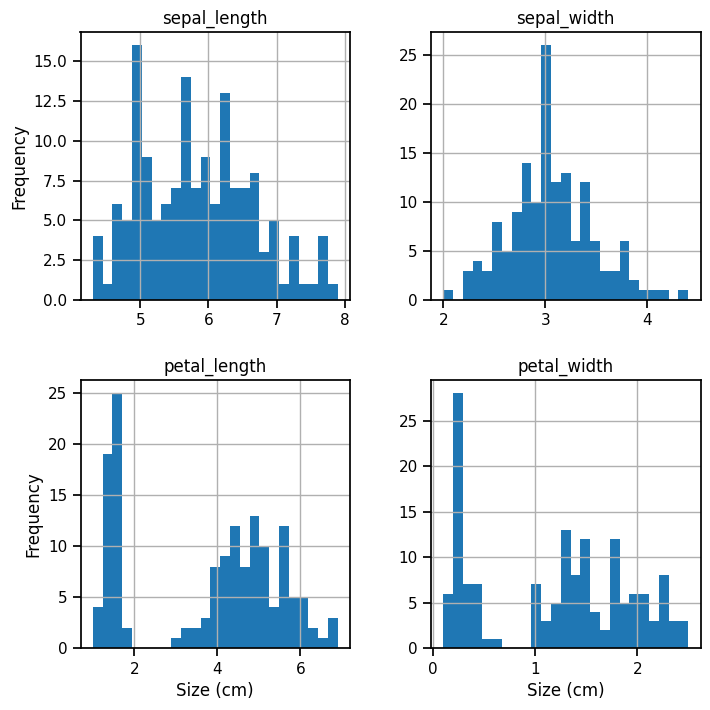

In [ ]:
axList = df.hist(bins=25, figsize=(8,8))

# Add some x- and y- labels to first column and last row
# Get the number of rows and columns in the subplot grid
num_rows, num_cols = axList.shape

for i in range(num_rows):
    for j in range(num_cols):
        ax = axList[i, j]
        if i == num_rows - 1:  # Check if it's the last row
            ax.set_xlabel('Size (cm)')

        if j == 0:  # Check if it's the first column
            ax.set_ylabel('Frequency')

# **all features in single boxplot**

In [ ]:
# First we have to reshape the data so there is
# only a single measurement in each column

plot_data = (df
             .set_index('species')
             .stack()
             .to_frame()
             .reset_index()
             .rename(columns={0:'size', 'level_1':'measurement'})
            )

plot_data.head()

,species,measurement,size
0,Iris-setosa,sepal_length,5.1
1,Iris-setosa,sepal_width,3.5
2,Iris-setosa,petal_length,1.4
3,Iris-setosa,petal_width,0.2
4,Iris-setosa,sepal_length,4.9


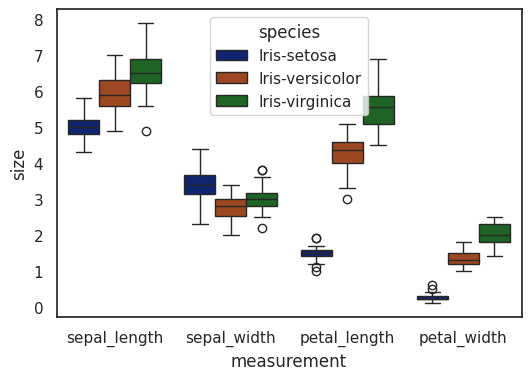

In [ ]:
sns.set_style('white')
sns.set_context('notebook')
sns.set_palette('dark')

f = plt.figure(figsize=(6,4))
sns.boxplot(x='measurement', y='size',
            hue='species', data=plot_data);

# **Pairplot to examine the correlations**

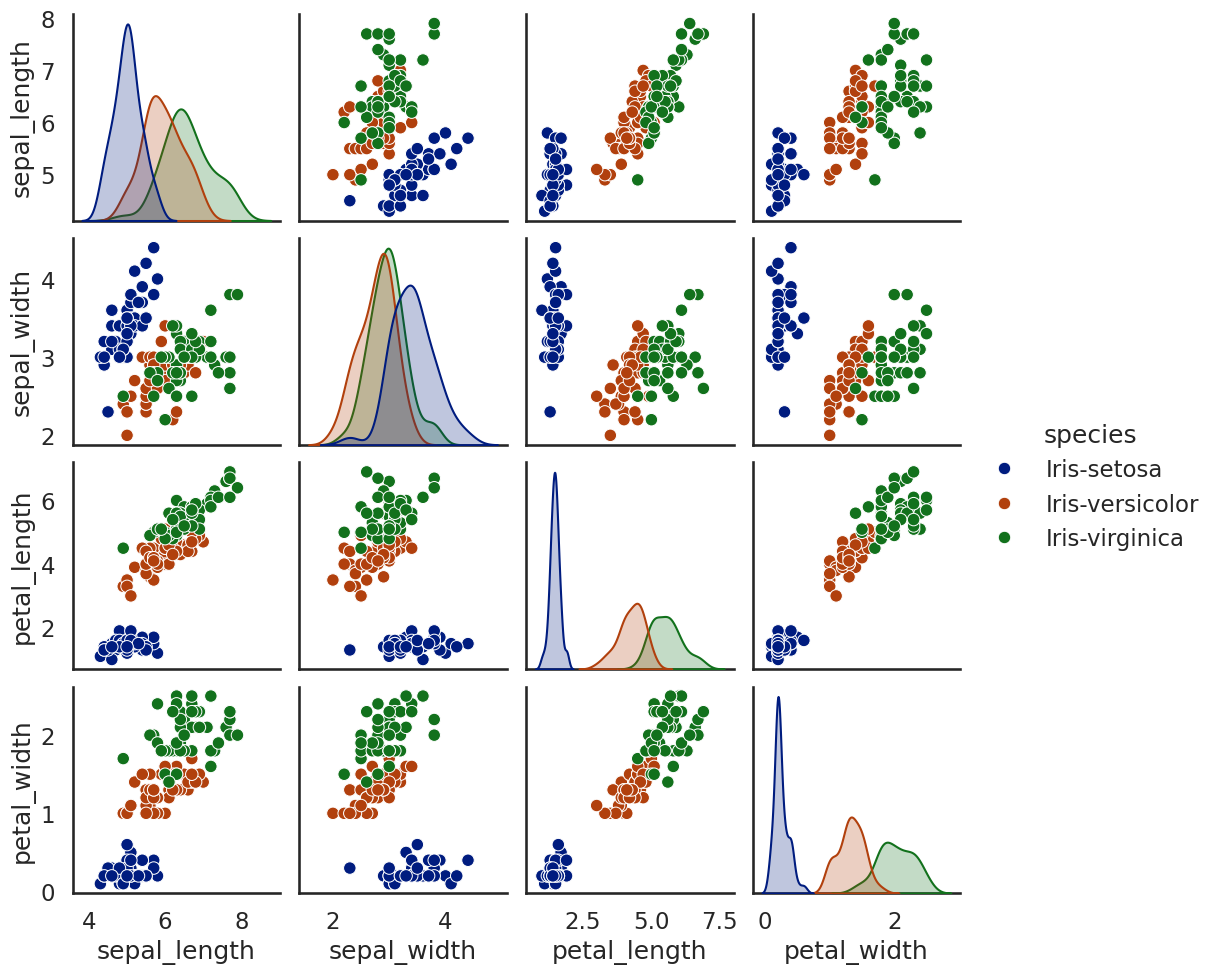

In [ ]:
sns.set_context('talk')
sns.pairplot(df, hue='species');

In [ ]:
from sklearn import datasets
from sklearn.cluster import KMeans
#load the data
iris = datasets.load_iris()

print(iris.data)

[[5.1 3.5 1.4 0.2]
 [4.9 3.  1.4 0.2]
 [4.7 3.2 1.3 0.2]
 [4.6 3.1 1.5 0.2]
 [5.  3.6 1.4 0.2]
 [5.4 3.9 1.7 0.4]
 [4.6 3.4 1.4 0.3]
 [5.  3.4 1.5 0.2]
 [4.4 2.9 1.4 0.2]
 [4.9 3.1 1.5 0.1]
 [5.4 3.7 1.5 0.2]
 [4.8 3.4 1.6 0.2]
 [4.8 3.  1.4 0.1]
 [4.3 3.  1.1 0.1]
 [5.8 4.  1.2 0.2]
 [5.7 4.4 1.5 0.4]
 [5.4 3.9 1.3 0.4]
 [5.1 3.5 1.4 0.3]
 [5.7 3.8 1.7 0.3]
 [5.1 3.8 1.5 0.3]
 [5.4 3.4 1.7 0.2]
 [5.1 3.7 1.5 0.4]
 [4.6 3.6 1.  0.2]
 [5.1 3.3 1.7 0.5]
 [4.8 3.4 1.9 0.2]
 [5.  3.  1.6 0.2]
 [5.  3.4 1.6 0.4]
 [5.2 3.5 1.5 0.2]
 [5.2 3.4 1.4 0.2]
 [4.7 3.2 1.6 0.2]
 [4.8 3.1 1.6 0.2]
 [5.4 3.4 1.5 0.4]
 [5.2 4.1 1.5 0.1]
 [5.5 4.2 1.4 0.2]
 [4.9 3.1 1.5 0.2]
 [5.  3.2 1.2 0.2]
 [5.5 3.5 1.3 0.2]
 [4.9 3.6 1.4 0.1]
 [4.4 3.  1.3 0.2]
 [5.1 3.4 1.5 0.2]
 [5.  3.5 1.3 0.3]
 [4.5 2.3 1.3 0.3]
 [4.4 3.2 1.3 0.2]
 [5.  3.5 1.6 0.6]
 [5.1 3.8 1.9 0.4]
 [4.8 3.  1.4 0.3]
 [5.1 3.8 1.6 0.2]
 [4.6 3.2 1.4 0.2]
 [5.3 3.7 1.5 0.2]
 [5.  3.3 1.4 0.2]
 [7.  3.2 4.7 1.4]
 [6.4 3.2 4.5 1.5]
 [6.9 3.1 4.

In [ ]:
#Iris data Ground Truth result
print(iris.target)


In [ ]:
print(iris.DESCR)

.. _iris_dataset:

Iris plants dataset
--------------------

**Data Set Characteristics:**

:Number of Instances: 150 (50 in each of three classes)
:Number of Attributes: 4 numeric, predictive attributes and the class
:Attribute Information:
    - sepal length in cm
    - sepal width in cm
    - petal length in cm
    - petal width in cm
    - class:
            - Iris-Setosa
            - Iris-Versicolour
            - Iris-Virginica

:Summary Statistics:

============== ==== ==== ======= ===== ====================
                Min  Max   Mean    SD   Class Correlation
============== ==== ==== ======= ===== ====================
sepal length:   4.3  7.9   5.84   0.83    0.7826
sepal width:    2.0  4.4   3.05   0.43   -0.4194
petal length:   1.0  6.9   3.76   1.76    0.9490  (high!)
petal width:    0.1  2.5   1.20   0.76    0.9565  (high!)
============== ==== ==== ======= ===== ====================

:Missing Attribute Values: None
:Class Distribution: 33.3% for each of 3 classes.
:Cr

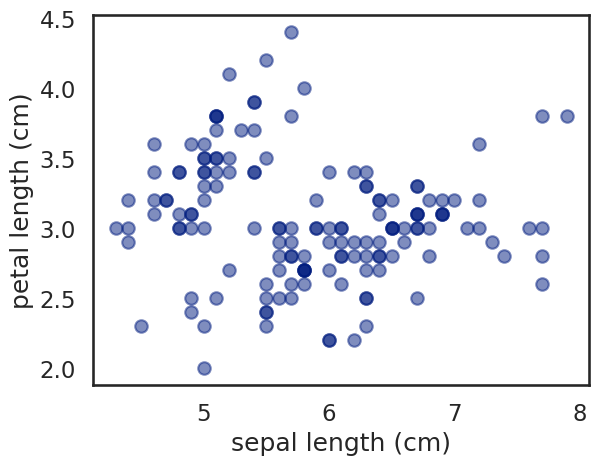

In [ ]:
samples = iris.data
x = samples[:,0]
y = samples[:,1]

sepal_length_width = np.array(list(zip(x, y)))
plt.scatter(x, y, alpha=0.5)

plt.xlabel('sepal length (cm)')
plt.ylabel('petal length (cm)')

plt.show()

# Clustering using k-means from scikit-learn library

In [ ]:
k=3
model = KMeans(n_clusters = k)

In [ ]:
#use .fit() method to fit the model to the samples
model.fit(samples)

KMeans(n_clusters=3)

In [ ]:
# Use .predict() to determine the labels of samples
labels = model.predict(samples)
# Print the labels
print(labels)

[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 2 1 2 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 2 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 2 1 2 2 2 2 1 2 2 2 2
 2 2 1 1 2 2 2 2 1 2 1 2 1 2 2 1 1 2 2 2 2 2 1 2 2 2 2 1 2 2 2 1 2 2 2 1 2
 2 1]


# Train-test splits

In [ ]:
data = df.copy()
data.head()

,sepal_length,sepal_width,petal_length,petal_width,species
Id,,,,,
1,5.1,3.5,1.4,0.2,Iris-setosa
2,4.9,3.0,1.4,0.2,Iris-setosa
3,4.7,3.2,1.3,0.2,Iris-setosa
4,4.6,3.1,1.5,0.2,Iris-setosa
5,5.0,3.6,1.4,0.2,Iris-setosa


In [ ]:
from sklearn.model_selection import train_test_split

target = 'species'
X = data[['sepal_length', 'sepal_width', 'petal_length', 'petal_width']]
y = data[target]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 11)
# it shows 80% of data is split for training and 20% of the data goes to testing.
print(X_train.shape)
print(X_test.shape)

(120, 4)
(30, 4)


# Logistic Regression

**Logistic Regression  is similar to Linear Regression but the target variable is categorical. It predicts the probability of an observation belonging to a category of the target variable. Sigmoid Function = ey / (1+ey) where ey = [co-efficients-matrix][feature-vector]**
![](https://lh3.googleusercontent.com/proxy/p9PrwtbztSEpP-KezpfM3HQBBOe0xqZAu_eAtlBgw-PnCzfgZhRoeysYkHyVjV8DppFcKT7ZaJTQ88SHXMfAU0PkdpXptmPuqWsjk0vSUKAclOYMBDMQVE9jm3U)

Source- https://www.google.com/url?sa=i&url=http%3A%2F%2Fjuangabrielgomila.com%2Fen%2Flogistic-regression-derivation%2F&psig=AOvVaw0NnEbsC6SfeEZ5QqseuWbG&ust=1617370255285000&source=images&cd=vfe&ved=0CAkQjhxqFwoTCMj2rO-T3e8CFQAAAAAdAAAAABAD

*Import the necessary libraries from sciki-learn package*

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn import metrics
lr = LogisticRegression()
lr.fit(X_train, y_train)
y_pred = lr.predict(X_test)
print('Test Accuracy for Scikit-Learn model:', metrics.accuracy_score(y_test, y_pred)* 100,'%')

Test Accuracy for Scikit-Learn model: 93.33333333333333 %


# Evaluation Metrics
1. 	Jaccard-index
2.	Confusion matrix
3.	Logloss
4.  F1-Score

In [ ]:
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred))

                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00         9
Iris-versicolor       0.83      1.00      0.91        10
 Iris-virginica       1.00      0.82      0.90        11

       accuracy                           0.93        30
      macro avg       0.94      0.94      0.94        30
   weighted avg       0.94      0.93      0.93        30



**About Dataset**

**Context**

The two datasets are related to red and white variants of the Portuguese "Vinho Verde" wine. For more details, refer to [Cortez et al., 2009]. Due to privacy and logistic issues, only physicochemical (inputs) and sensory (the output) variables are available (e.g. there is no data about grape types, wine brand, wine selling price, etc.).

These datasets can be viewed as classification or regression tasks. The classes are ordered and not balanced (e.g. there are many more normal wines than excellent or poor ones). Outlier detection algorithms could be used to detect the few excellent or poor wines. Also, we are not sure if all input variables are relevant. So it could be interesting to test feature selection methods.

**Content**
For more information, read [Cortez et al., 2009].
Input variables (based on physicochemical tests):
1 - fixed acidity
2 - volatile acidity
3 - citric acid
4 - residual sugar
5 - chlorides
6 - free sulfur dioxide
7 - total sulfur dioxide
8 - density
9 - pH
10 - sulphates
11 - alcohol
Output variable (based on sensory data):
12 - quality (score between 0 and 10)

**Acknowledgements**
This dataset is also available from the UCI machine learning repository, https://archive.ics.uci.edu/ml/datasets/wine+quality, to get both the dataset i.e. red and white vinho verde wine samples, from the north of Portugal, please visit the above link.

Please include this citation if you plan to use this database:

P. Cortez, A. Cerdeira, F. Almeida, T. Matos and J. Reis.
Modeling wine preferences by data mining from physicochemical properties. In Decision Support Systems, Elsevier, 47(4):547-553, 2009.

**Inspiration**
We kagglers can apply several machine-learning algorithms to determine which physiochemical properties make a wine 'good'!

**Relevant papers**
P. Cortez, A. Cerdeira, F. Almeida, T. Matos and J. Reis. Modeling wine preferences by data mining from physicochemical properties.
In Decision Support Systems, Elsevier, 47(4):547-553, 2009.

In [ ]:
import pandas as pd

In [ ]:
test = pd.read_excel

In [ ]:
df_wine = pd.read_csv('/winequality-white.csv', sep=';')
display(df_wine.head())

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.0,0.27,0.36,20.7,0.045,45.0,170.0,1.0010,3.00,0.45,8.8,6
1,6.3,0.30,0.34,1.6,0.049,14.0,132.0,0.9940,3.30,0.49,9.5,6
2,8.1,0.28,0.40,6.9,0.050,30.0,97.0,0.9951,3.26,0.44,10.1,6
3,7.2,0.23,0.32,8.5,0.058,47.0,186.0,0.9956,3.19,0.40,9.9,6
4,7.2,0.23,0.32,8.5,0.058,47.0,186.0,0.9956,3.19,0.40,9.9,6


### Non-Graphical EDA for Wine Quality Dataset

Non-graphical EDA involves using statistical methods and data aggregations to understand the dataset. For the `df_wine` dataset, we can perform several non-graphical analyses to understand its structure, central tendencies, spread, and the distribution of its variables.

**1. Descriptive Statistics:** We can calculate summary statistics for all numerical columns, providing insights into their mean, median, standard deviation, quartiles, and range.

In [ ]:
print('--- Descriptive Statistics for Wine Quality Dataset ---')
display(df_wine.describe())

--- Descriptive Statistics for Wine Quality Dataset ---


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
count,4898.000000,4898.000000,4898.000000,4898.000000,4898.000000,4898.000000,4898.000000,4898.000000,4898.000000,4898.000000,4898.000000,4898.000000
mean,6.854788,0.278241,0.334192,6.391415,0.045772,35.308085,138.360657,0.994027,3.188267,0.489847,10.514267,5.877909
std,0.843868,0.100795,0.121020,5.072058,0.021848,17.007137,42.498065,0.002991,0.151001,0.114126,1.230621,0.885639
min,3.800000,0.080000,0.000000,0.600000,0.009000,2.000000,9.000000,0.987110,2.720000,0.220000,8.000000,3.000000
25%,6.300000,0.210000,0.270000,1.700000,0.036000,23.000000,108.000000,0.991723,3.090000,0.410000,9.500000,5.000000
50%,6.800000,0.260000,0.320000,5.200000,0.043000,34.000000,134.000000,0.993740,3.180000,0.470000,10.400000,6.000000
75%,7.300000,0.320000,0.390000,9.900000,0.050000,46.000000,167.000000,0.996100,3.280000,0.550000,11.400000,6.000000
max,14.200000,1.100000,1.660000,65.800000,0.346000,289.000000,440.000000,1.038980,3.820000,1.080000,14.200000,9.000000


**2. Value Counts for Categorical/Ordinal Data:** For the 'quality' column, which is an ordinal variable, checking value counts helps us understand the distribution of wine quality ratings.

In [ ]:
print('\n--- Value Counts for Wine Quality (Ordinal Variable) ---')
display(df_wine['quality'].value_counts().sort_index())


--- Value Counts for Wine Quality (Ordinal Variable) ---


,count
quality,
3,20
4,163
5,1457
6,2198
7,880
8,175
9,5


**Explanation of Answer:**

By examining these non-graphical outputs, we can immediately glean valuable insights:

*   **Descriptive Statistics:** For instance, `df_wine.describe()` shows the average `fixed acidity`, `pH`, `alcohol` content, and their variability. It also reveals the minimum and maximum values for each physicochemical property, helping to identify potential outliers or data ranges. We can see that 'quality' ranges from 3 to 9, with an average around 5.8.

*   **Value Counts for Quality:** `df_wine['quality'].value_counts()` directly shows how many wines fall into each quality rating (e.g., how many wines are rated '6', how many are '5', etc.). This immediately highlights if the dataset is balanced across different quality ratings or if certain ratings are more common. In this case, 'quality' ratings of 6, 5, and 7 are the most frequent.

Q1 **Describe all three data set in terms of following : how many features, their categories (num,text,categorical, nominal,ordinal etc), number of tuples, missing values.**

In [ ]:
print('--- Wine Quality Dataset Info ---')
df_wine.info()
print('\n--- Wine Quality Dataset Missing Values ---')
df_wine.isnull().sum()

--- Wine Quality Dataset Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4898 entries, 0 to 4897
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         4898 non-null   float64
 1   volatile acidity      4898 non-null   float64
 2   citric acid           4898 non-null   float64
 3   residual sugar        4898 non-null   float64
 4   chlorides             4898 non-null   float64
 5   free sulfur dioxide   4898 non-null   float64
 6   total sulfur dioxide  4898 non-null   float64
 7   density               4898 non-null   float64
 8   pH                    4898 non-null   float64
 9   sulphates             4898 non-null   float64
 10  alcohol               4898 non-null   float64
 11  quality               4898 non-null   int64  
dtypes: float64(11), int64(1)
memory usage: 459.3 KB

--- Wine Quality Dataset Missing Values ---


,0
fixed acidity,0
volatile acidity,0
citric acid,0
residual sugar,0
chlorides,0
free sulfur dioxide,0
total sulfur dioxide,0
density,0
pH,0
sulphates,0


### Dataset Descriptions

Here's a description of each dataset based on the current notebook state:

**1. Iris Dataset (`df`):**
*   **Number of Features:** 5
*   **Features and Categories:**
    *   `sepal_length` (Numerical, float64)
    *   `sepal_width` (Numerical, float64)
    *   `petal_length` (Numerical, float64)
    *   `petal_width` (Numerical, float64)
    *   `species` (Categorical/Nominal, object)
*   **Number of Tuples:** 150
*   **Missing Values:** None

**2. California Housing Dataset (loaded as `california_data`, described as 'Air Quality Dataset' in markdown cells):**
*   **Number of Features:** 9
*   **Features and Categories:**
    *   `longitude` (Numerical, float64)
    *   `latitude` (Numerical, float64)
    *   `housing_median_age` (Numerical, float64)
    *   `total_rooms` (Numerical, float64)
    *   `total_bedrooms` (Numerical, float64)
    *   `population` (Numerical, float64)
    *   `households` (Numerical, float64)
    *   `median_income` (Numerical, float64)
    *   `median_house_value` (Numerical, float64)
*   **Number of Tuples:** 17,000
*   **Missing Values:** None

**3. Wine Quality Dataset (`df_wine`):**
*   **Number of Features:** 12
*   **Features and Categories:**
    *   `fixed acidity` (Numerical, float64)
    *   `volatile acidity` (Numerical, float64)
    *   `citric acid` (Numerical, float64)
    *   `residual sugar` (Numerical, float64)
    *   `chlorides` (Numerical, float64)
    *   `free sulfur dioxide` (Numerical, float64)
    *   `total sulfur dioxide` (Numerical, float64)
    *   `density` (Numerical, float64)
    *   `pH` (Numerical, float64)
    *   `sulphates` (Numerical, float64)
    *   `alcohol` (Numerical, float64)
    *   `quality` (Numerical/Ordinal, int64) - This is the target variable, an ordinal score.
*   **Number of Tuples:** 4,898
*   **Missing Values:** None



In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).



Q2 **In IRIS data set which non graphical EDA is performed ? **

Ans. For the Iris dataset, the following non-graphical Exploratory Data Analysis (EDA) techniques were performed:

Displaying the head of the DataFrame (df.head()): This provides a quick overview of the data structure and initial values.
Calculating descriptive statistics (df.describe()): This generated summary statistics like count, mean, standard deviation, min, max, and quartiles for numerical columns.
Calculating median values grouped by species (df.groupby('species').median()): This provided insight into the central tendency of features for each Iris species.
Creating a custom statistics DataFrame (new_df): This involved calculating ranges and selecting specific descriptive statistics (mean, range, 25%, 50% (median), 75%) for further examination.
Performing multiple aggregations by species (df.groupby('species').agg(['mean', 'median']) and df.groupby('species').agg(agg_dict)): These operations calculated various statistics (mean, median, max) for different features, grouped by the 'species' column, to understand differences between the groups.
Checking for missing values (implied by the dataset description in cell f5682662): Although not explicitly shown with df.isnull().sum() for df, this is a standard non-graphical EDA step to ensure data completeness, and the description confirms no missing values.

Q3 **In  Air Quality data set which graph is used to perform multivariate analysis?**

Ans. In the notebook's 'Air Quality data set' section, which uses the California Housing dataset, the following graphs are used to perform multivariate analysis:

Correlation Matrix Heatmap (Cell QzTjEpqSv4fc): This heatmap visualizes the pairwise correlations between median_house_value, median_income, total_rooms, and total_bedrooms. By showing the relationships among multiple numerical variables simultaneously, it provides a multivariate view of their associations.

Pairplot (Cell x-ntrwQcv4fd): This plot generates a grid of scatter plots for each pair of variables (median_house_value, median_income, total_rooms, total_bedrooms), and histograms (or KDEs) for each individual variable on the diagonal. This is a powerful tool for understanding the relationships and distributions of multiple variables in a dataset.



Q4**In Wine quality data set can you do non graphical EDA ? Explain your answer.**
Ans. es, absolutely! Non-graphical Exploratory Data Analysis is very useful for the Wine Quality dataset. It helps us understand the data's characteristics without relying on visualizations.

I'll explain how, and then generate code to perform some key non-graphical EDA steps on the df_wine DataFrame, such as obtaining descriptive statistics and checking the distribution of the 'quality' variable.

The non-graphical EDA for the Wine Quality dataset (df_wine) has been successfully executed, providing some valuable insights:

Descriptive Statistics: The df_wine.describe() output shows the average fixed acidity (around 6.85), pH (around 3.19), and alcohol content (around 10.51), along with their variability (standard deviation), and ranges (min/max). We can also see that the quality ratings range from 3 to 9, with an average of approximately 5.88.

Value Counts for Quality: The df_wine['quality'].value_counts() reveals the distribution of wine quality ratings. The most frequent quality ratings are 6 (2198 wines), 5 (1457 wines), and 7 (880 wines). This indicates that the dataset is skewed towards wines of moderate quality, with very few wines rated as 3 or 9. This kind of imbalance can be important for modeling tasks.

I have successfully performed and explained the non-graphical EDA for the Wine Quality dataset. We observed descriptive statistics for all numerical features, including measures like mean, standard deviation, and min/max values. We also examined the value counts for the 'quality' variable, which revealed an imbalanced distribution, with most wines rated 5, 6, or 7.